In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data types and nulls
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# TotalCharges is stored as object — fix this
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Nulls after coerce:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulls after coerce:
TotalCharges    11
dtype: int64


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.5%


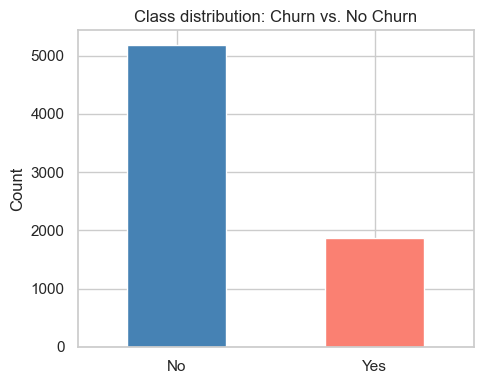

In [5]:
# Class balance — key for choosing eval metrics
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f'Churn rate: {churn_counts["Yes"] / len(df):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
churn_counts.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
ax.set_title('Class distribution: Churn vs. No Churn')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

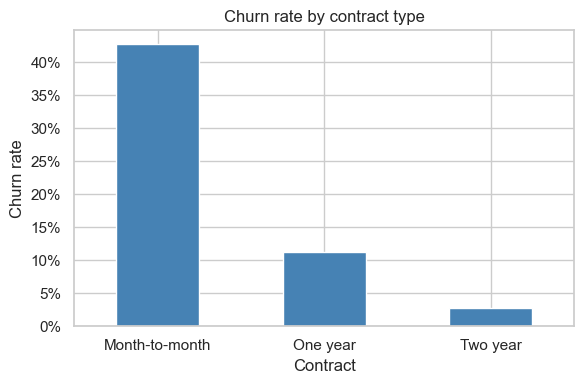

In [6]:
# Churn rate by contract type — good interview talking point
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean()
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
contract_churn.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Churn rate by contract type')
ax.set_ylabel('Churn rate')
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

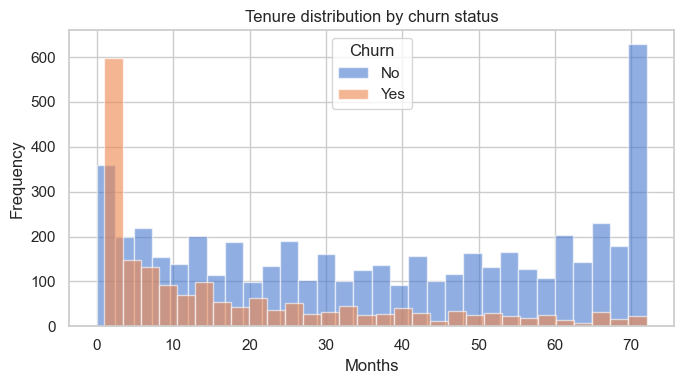

In [7]:
# Tenure distribution by churn status
fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in df.groupby('Churn'):
    grp['tenure'].plot(kind='hist', bins=30, alpha=0.6, label=label, ax=ax)
ax.set_title('Tenure distribution by churn status')
ax.set_xlabel('Months')
ax.legend(title='Churn')
plt.tight_layout()
plt.show()

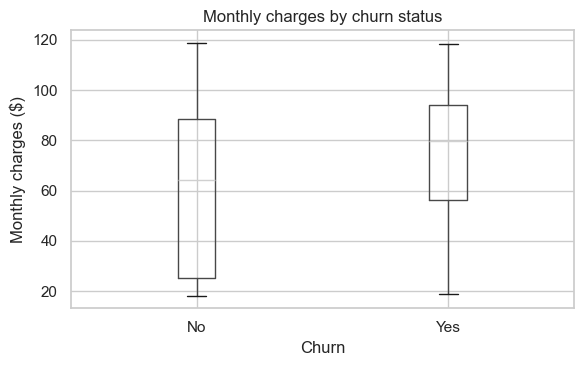

In [8]:
# Monthly charges vs churn
fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax)
ax.set_title('Monthly charges by churn status')
ax.set_xlabel('Churn')
ax.set_ylabel('Monthly charges ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

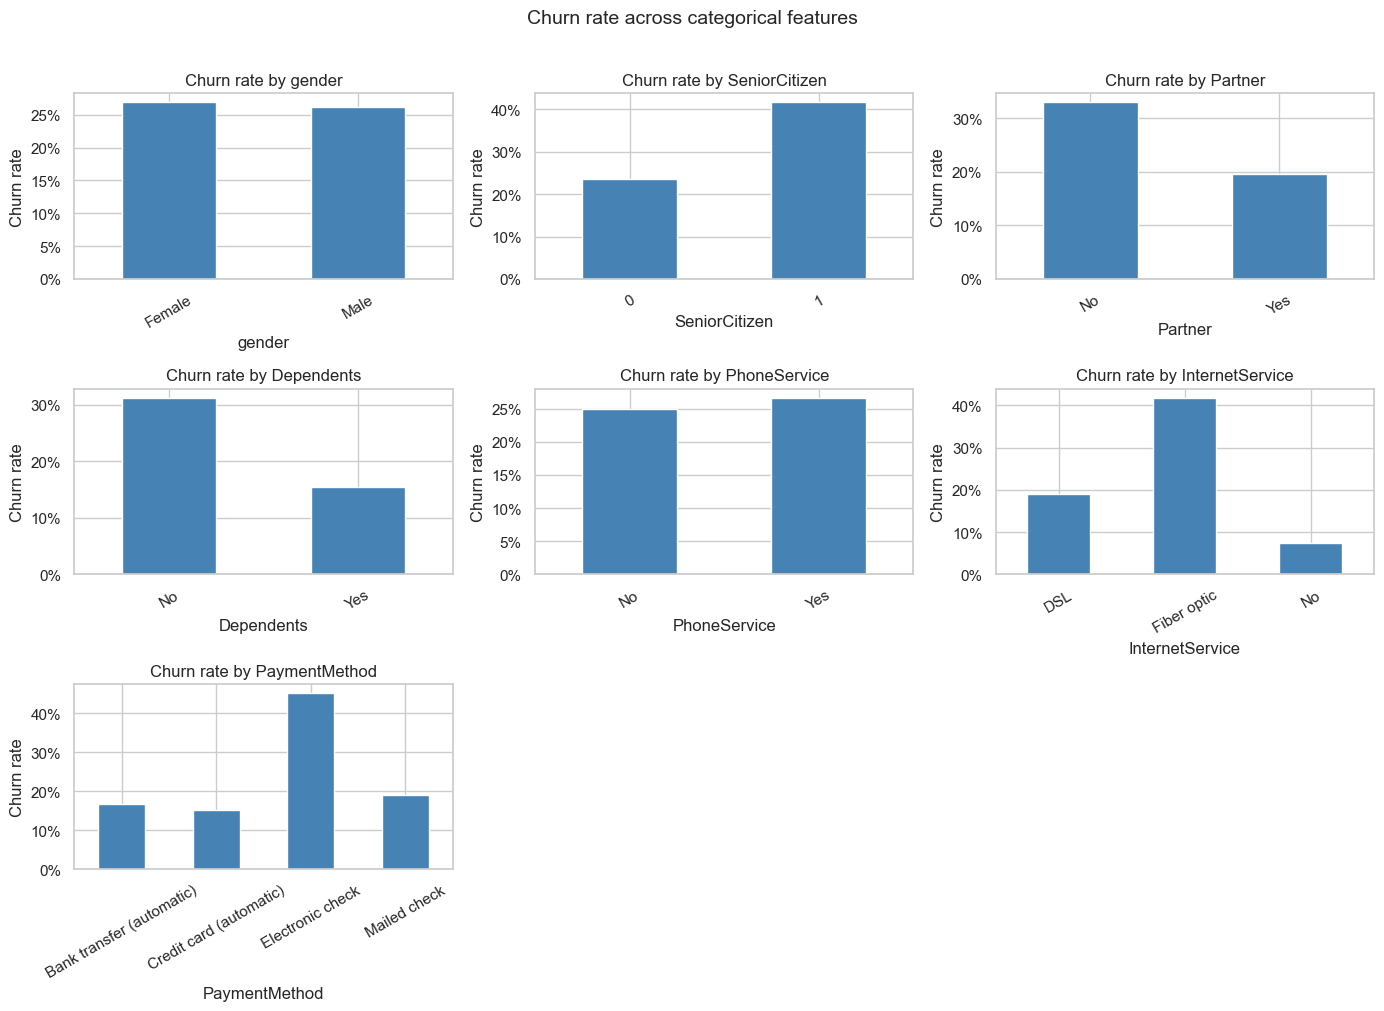

In [9]:
# Churn rate across categorical features
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    ct.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Churn rate across categorical features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Key takeaways from EDA

- **Class imbalance**: ~26% churn rate. We'll need to account for this (SMOTE or class weights).
- **Tenure**: churners tend to have much shorter tenure. Strong signal.
- **Contract type**: month-to-month customers churn far more. Intuitive — less commitment.
- **Monthly charges**: churners pay slightly more monthly. Could reflect premium plans with more competitors.
- **Internet service**: fiber optic customers churn more than DSL or no-internet customers.

These are exactly the kinds of patterns an interviewer will ask you to explain and reason about.